In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
class CustomDataset(Dataset):
    
    def __init__(self, data_input):
        """
        Most basic pytorch dataset for autoencoder
        
        Args:
            data_input (array): input images
        """
        self.img_train = data_input

    def __len__(self):
        return len(self.img_train)

    def __getitem__(self, idx):
        image = self.img_train[idx]
        return {'input': image, 'label': image}

In [3]:
ds_ifs = xr.open_dataset('/glade/derecho/scratch/dcalhoun/ecmwf_ifs/sample_ifs.nc', decode_times=False)
ds_analysis = xr.open_dataset('/glade/derecho/scratch/dcalhoun/ecmwf_ifs/sample_ifs_analysis.nc', decode_times=False)
ds_error = ds_ifs['t2m'].isel(time=0) - ds_analysis['t2m'].isel(time=0) # 1 day, 9801 grid cells

In [4]:
ds_samples = np.stack([
                    ds_error.stack(newdim=['latitude','longitude']).values,
                    ds_error.stack(newdim=['latitude','longitude']).latitude.values,
                    ds_error.stack(newdim=['latitude','longitude']).longitude.values,
                    np.repeat(ds_error.stack(newdim=['latitude','longitude']).time.values, 
                              ds_error.stack(newdim=['latitude','longitude']).latitude.values.shape[0])
                ], axis=1)

In [5]:
ds_samples[0], ds_samples.shape

(array([-3.3538047e-01,  4.5000000e+01, -8.5000000e+01,  1.0168320e+06]),
 (9801, 4))

In [6]:
# Normalize
ds_samples[:,0] = (ds_samples[:,0] - ds_samples[:,0].mean()) / (ds_samples[:,0].max() - ds_samples[:,0].min())
ds_samples[:,1] = (ds_samples[:,1] - ds_samples[:,1].mean()) / (ds_samples[:,1].max() - ds_samples[:,1].min())
ds_samples[:,2] = (ds_samples[:,2] - ds_samples[:,2].mean()) / (ds_samples[:,2].max() - ds_samples[:,2].min())
ds_samples[:,3] = 1

In [15]:
error_dataset = CustomDataset(ds_samples)

In [16]:
train_dataloader = DataLoader(error_dataset, batch_size=16, shuffle=True)

In [17]:
error_dataset.__getitem__(1000)

{'input': array([ 0.08624024,  0.4       , -0.23333333,  1.        ]),
 'label': array([ 0.08624024,  0.4       , -0.23333333,  1.        ])}

In [18]:
for i in train_dataloader:
    print(i['input'].shape)
    break

torch.Size([16, 4])


In [22]:
class AE(torch.nn.Module):
    
    def __init__(self, **kwargs):
        
        super().__init__()
        
        self.encoder_hidden_layer = torch.nn.Linear(
            in_features=4, out_features=2
        )
        self.encoder_output_layer = torch.nn.Linear(
            in_features=2, out_features=1
        )
        self.decoder_hidden_layer = torch.nn.Linear(
            in_features=1, out_features=2
        )
        self.decoder_output_layer = torch.nn.Linear(
            in_features=2, out_features=4
        )

    def forward(self, features):
        
        activation = self.encoder_hidden_layer(features)
        activation = torch.relu(activation)
        
        code = self.encoder_output_layer(activation)
        code = torch.relu(code)
        
        activation = self.decoder_hidden_layer(code)
        activation = torch.relu(activation)
        
        activation = self.decoder_output_layer(activation)
        reconstructed = torch.relu(activation)
        
        return reconstructed

In [23]:
def train(model, dataloader, criterion):
    """
    Training function.
    Args:
        model (torch): pytorch neural network
        dataloader (torch): pytorch dataloader
        criterion: loss
    """
    model.train()
    running_loss = 0.0
    
    for data in dataloader:
        
        img_input = data['input']
        img_label = data['label']

        outputs = model(img_input.float())
        
        loss = criterion(outputs, img_label.float())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    train_loss = running_loss / len(dataloader)
    
    return train_loss

In [24]:
model = AE()

In [26]:
LEARNING_RATE = 1e-4

# the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# the loss function
criterion = torch.nn.MSELoss()

In [27]:
NUM_EPOCHS = 100
train_loss = []

for enum, epoch in enumerate(range(NUM_EPOCHS)):
    
    t_loss = train(model, train_dataloader, criterion)
    train_loss.append(t_loss)
    
    print(f"Epoch {epoch + 1} of {NUM_EPOCHS}; Train Loss: {t_loss:.4f}")

Epoch 1 of 100; Train Loss: 0.1770
Epoch 2 of 100; Train Loss: 0.1470
Epoch 3 of 100; Train Loss: 0.1231
Epoch 4 of 100; Train Loss: 0.1041
Epoch 5 of 100; Train Loss: 0.0892
Epoch 6 of 100; Train Loss: 0.0775
Epoch 7 of 100; Train Loss: 0.0685
Epoch 8 of 100; Train Loss: 0.0616
Epoch 9 of 100; Train Loss: 0.0564
Epoch 10 of 100; Train Loss: 0.0525
Epoch 11 of 100; Train Loss: 0.0498
Epoch 12 of 100; Train Loss: 0.0480
Epoch 13 of 100; Train Loss: 0.0469
Epoch 14 of 100; Train Loss: 0.0464
Epoch 15 of 100; Train Loss: 0.0462
Epoch 16 of 100; Train Loss: 0.0461
Epoch 17 of 100; Train Loss: 0.0461
Epoch 18 of 100; Train Loss: 0.0461
Epoch 19 of 100; Train Loss: 0.0461
Epoch 20 of 100; Train Loss: 0.0461
Epoch 21 of 100; Train Loss: 0.0461
Epoch 22 of 100; Train Loss: 0.0461
Epoch 23 of 100; Train Loss: 0.0461
Epoch 24 of 100; Train Loss: 0.0461
Epoch 25 of 100; Train Loss: 0.0461
Epoch 26 of 100; Train Loss: 0.0461
Epoch 27 of 100; Train Loss: 0.0461
Epoch 28 of 100; Train Loss: 0.0461
E

KeyboardInterrupt: 

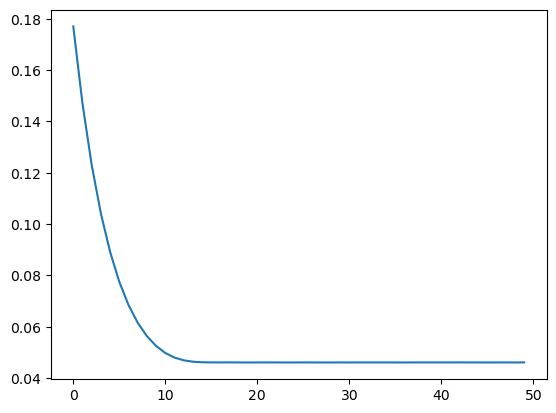

In [35]:
plt.plot(train_loss)
plt.savefig('AE_babyerror_train_curve.png')
plt.show()